In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 168MB/s]



In [ ]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


**Importing the dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_413.jpg', 'with_mask_777.jpg', 'with_mask_1046.jpg', 'with_mask_1914.jpg', 'with_mask_3617.jpg']
['with_mask_2856.jpg', 'with_mask_751.jpg', 'with_mask_1632.jpg', 'with_mask_430.jpg', 'with_mask_3663.jpg']


In [ ]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2916.jpg', 'without_mask_1090.jpg', 'without_mask_763.jpg', 'without_mask_910.jpg', 'without_mask_449.jpg']
['without_mask_3744.jpg', 'without_mask_3584.jpg', 'without_mask_3427.jpg', 'without_mask_1915.jpg', 'without_mask_3622.jpg']


In [ ]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask --> 1

without mask --> 0

In [ ]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [ ]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [ ]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


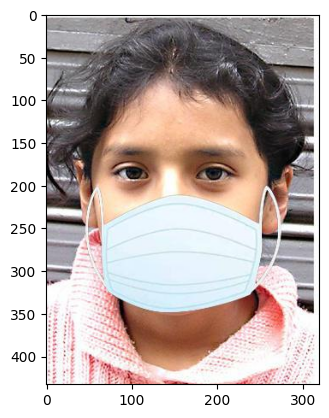

In [ ]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1914.jpg')
imgplot = plt.imshow(img)
plt.show()

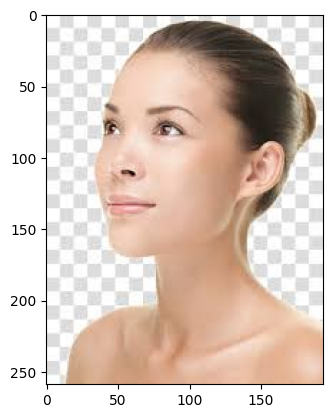

In [ ]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [ ]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[ 27,  25,  30],
        [ 28,  24,  29],
        [ 27,  22,  28],
        ...,
        [ 94,  83,  81],
        [116, 106, 104],
        [ 86,  76,  74]],

       [[ 22,  20,  23],
        [ 22,  19,  21],
        [ 21,  17,  21],
        ...,
        [ 69,  59,  57],
        [ 70,  60,  58],
        [103,  93,  91]],

       [[ 21,  21,  23],
        [ 19,  18,  20],
        [ 18,  15,  19],
        ...,
        [102,  92,  90],
        [ 70,  60,  58],
        [ 55,  45,  43]],

       ...,

       [[179, 189, 190],
        [179, 189, 191],
        [181, 192, 194],
        ...,
        [235, 211, 185],
        [238, 216, 192],
        [243, 221, 197]],

       [[180, 190, 192],
        [181, 190, 194],
        [186, 194, 199],
        ...,
        [235, 212, 185],
        [239, 218, 194],
        [245, 224, 200]],

       [[185, 192, 200],
        [185, 192, 199],
        [187, 194, 202],
        ...,
        [235, 215, 186],
        [239, 220, 193],
        [244, 227, 199]]], dtype=uint8)
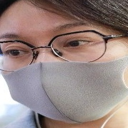

In [ ]:
data[0]

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
data[0].shape

(128, 128, 3)

In [ ]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [ ]:
print(Y)

[1 1 1 ... 0 0 0]


 **Train Test Split**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 24,  27,  34],
        [ 22,  25,  32],
        [ 26,  27,  32],
        ...,
        [ 78,  65,  72],
        [ 93,  78,  85],
        [113,  96, 104]],

       [[ 26,  26,  34],
        [ 26,  26,  34],
        [ 29,  30,  35],
        ...,
        [ 73,  60,  67],
        [ 84,  69,  76],
        [ 99,  82,  90]],

       [[ 30,  29,  37],
        [ 29,  29,  37],
        [ 30,  30,  35],
        ...,
        [ 71,  58,  66],
        [ 88,  71,  80],
        [ 99,  82,  92]],

       ...,

       [[253, 253, 251],
        [253, 253, 251],
        [253, 253, 253],
        ...,
        [ 49,  52,  59],
        [ 45,  48,  55],
        [ 41,  44,  51]],

       [[253, 254, 251],
        [253, 255, 252],
        [254, 255, 253],
        ...,
        [ 47,  50,  57],
        [ 44,  47,  54],
        [ 39,  42,  49]],

       [[252, 254, 250],
        [252, 254, 250],
        [252, 254, 251],
        ...,
        [ 44,  47,  54],
        [ 42,  45,  52],
        [ 38,  41,  48]]], dtype=uint8)
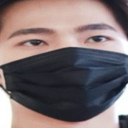

In [ ]:
X_train[0]

In [ ]:
X_train_scaled[0]

array([[[0.09411765, 0.10588235, 0.13333333],
        [0.08627451, 0.09803922, 0.1254902 ],
        [0.10196078, 0.10588235, 0.1254902 ],
        ...,
        [0.30588235, 0.25490196, 0.28235294],
        [0.36470588, 0.30588235, 0.33333333],
        [0.44313725, 0.37647059, 0.40784314]],

       [[0.10196078, 0.10196078, 0.13333333],
        [0.10196078, 0.10196078, 0.13333333],
        [0.11372549, 0.11764706, 0.1372549 ],
        ...,
        [0.28627451, 0.23529412, 0.2627451 ],
        [0.32941176, 0.27058824, 0.29803922],
        [0.38823529, 0.32156863, 0.35294118]],

       [[0.11764706, 0.11372549, 0.14509804],
        [0.11372549, 0.11372549, 0.14509804],
        [0.11764706, 0.11764706, 0.1372549 ],
        ...,
        [0.27843137, 0.22745098, 0.25882353],
        [0.34509804, 0.27843137, 0.31372549],
        [0.38823529, 0.32156863, 0.36078431]],

       ...,

       [[0.99215686, 0.99215686, 0.98431373],
        [0.99215686, 0.99215686, 0.98431373],
        [0.99215686, 0

**Building a Convolutional Neural Networks (CNN)**

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(2, activation='softmax'))

In [ ]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=25)

Epoch 1/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - acc: 0.7953 - loss: 0.4665 - val_acc: 0.8678 - val_loss: 0.3051
Epoch 2/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8784 - loss: 0.2969 - val_acc: 0.8893 - val_loss: 0.2663
Epoch 3/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8976 - loss: 0.2612 - val_acc: 0.8992 - val_loss: 0.2491
Epoch 4/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9255 - loss: 0.1983 - val_acc: 0.9091 - val_loss: 0.2451
Epoch 5/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9349 - loss: 0.1708 - val_acc: 0.9157 - val_loss: 0.2871
Epoch 6/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9463 - loss: 0.1406 - val_acc: 0.9091 - val_loss: 0.2651
Epoch 7/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9511 - loss: 0.1325 - val_acc: 0.9339 - val_loss: 0.2633
Epoch 8/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9586 - loss: 0.1155 - val_acc: 0.9372 - val_loss: 0.3082
Epoch 9/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms

**Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9252 - loss: 0.4118
Test Accuracy = 0.9252150654792786


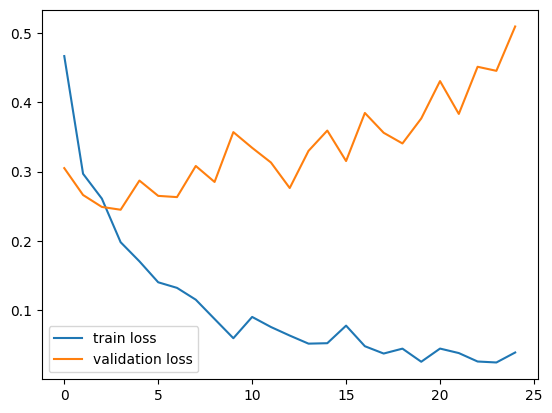

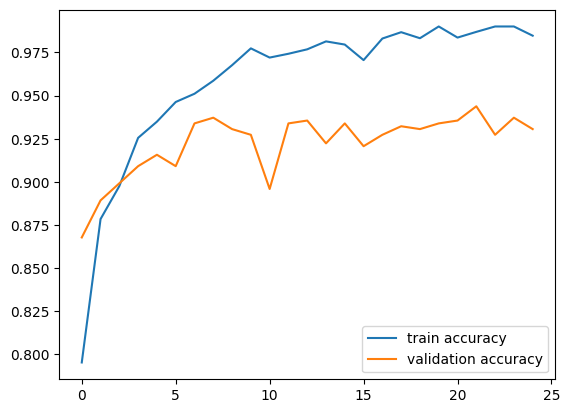

In [ ]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/data/without_mask/without_mask_100.jpg


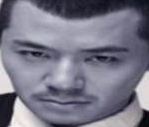

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw Prediction: [[1.000000e+00 6.589024e-10]]
0
The person in the image is not wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

# ✅ FIX: convert BGR → RGB
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print("Raw Prediction:", input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')